/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4814 - loss: 1.4425 - val_accuracy: 0.5525 - val_loss: 1.2719
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6148 - loss: 1.1007 - val_accuracy: 0.6467 - val_loss: 1.0217
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 48ms/step - accuracy: 0.6615 - loss: 0.9709 - val_accuracy: 0.6221 - val_loss: 1.1050
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.6931 - loss: 0.8793 - val_accuracy: 0.6651 - val_loss: 0.9778
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.7209 - loss: 0.8065 - val_accuracy: 0.6706 - val_loss: 0.9679
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6706 - loss: 0.9679
Test Loss: 0.9679
Test Accuracy: 0.6706
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      1000
           1       0.87      0.76      0.81      1000


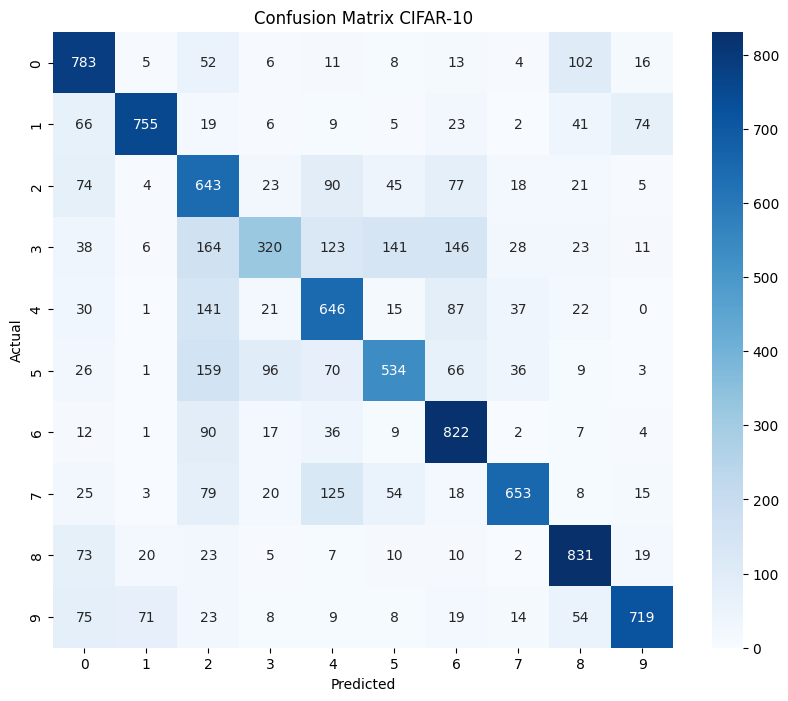

Shape x_train : (50000, 32, 32, 3)
Shape y_train : (50000, 1)
Shape x_test  : (10000, 32, 32, 3)
Shape y_test  : (10000, 1)

Dtype x_train : float64
Dtype y_train : uint8


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalisasi data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Membuat model CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# Evaluasi model
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Prediksi
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix CIFAR-10')
plt.show()

print("Shape x_train :", x_train.shape)
print("Shape y_train :", y_train.shape)
print("Shape x_test  :", x_test.shape)
print("Shape y_test  :", y_test.shape)

print("\nDtype x_train :", x_train.dtype)
print("Dtype y_train :", y_train.dtype)